# Phase 23 — Analysis & Visualization

Ανάλυση του best μοντέλου (BERT-base + Focal Loss) στο validation set.

**Περιεχόμενα:**
1. Confusion Matrix — hazard & product
2. Class-wise F1 scores
3. Error Analysis — ποια δείγματα κάνει λάθος
4. Ablation Study — title-only vs title+text

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded!')

Libraries loaded!


In [13]:
train = pd.read_csv('train.csv')
valid = pd.read_csv('valid.csv')

train_full = pd.concat([train, valid], ignore_index=True)

le_hazard  = LabelEncoder()
le_product = LabelEncoder()
le_hazard.fit(train_full['hazard-category'])
le_product.fit(train_full['product-category'])

# Φόρτωση validation probabilities
valid_hazard_probs  = np.load('bertbase_focal_trainonly_valid_hazard_probs.npy')
valid_product_probs = np.load('bertbase_focal_trainonly_valid_product_probs.npy')

# Predictions
pred_hazard  = le_hazard.inverse_transform(valid_hazard_probs.argmax(axis=1))
pred_product = le_product.inverse_transform(valid_product_probs.argmax(axis=1))

true_hazard  = valid['hazard-category'].values
true_product = valid['product-category'].values

print(f'Validation samples: {len(valid)}')
print(f'Hazard classes:  {len(le_hazard.classes_)}')
print(f'Product classes: {len(le_product.classes_)}')

Validation samples: 565
Hazard classes:  10
Product classes: 22


In [14]:
# Official ST1 Score
def official_st1_score(y_true_hazard, y_pred_hazard,
                       y_true_product, y_pred_product, verbose=True):
    f1_hazard = f1_score(y_true_hazard, y_pred_hazard, average='macro', zero_division=0)
    mask = (np.array(y_true_hazard) == np.array(y_pred_hazard))
    f1_product = f1_score(
        np.array(y_true_product)[mask],
        np.array(y_pred_product)[mask],
        average='macro', zero_division=0
    ) if mask.sum() > 0 else 0.0
    score = (f1_hazard + f1_product) / 2
    if verbose:
        print(f'macro-F1 Hazard:                    {f1_hazard:.4f}')
        print(f'Σωστά hazard predictions:           {mask.sum()}/{len(mask)} ({100*mask.mean():.1f}%)')
        print(f'macro-F1 Product (given correct h): {f1_product:.4f}')
        print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
        print(f'OFFICIAL ST1 SCORE:                 {score:.4f}')
    return score

print('=== BERT-base + Focal Loss (Validation) ===')
score = official_st1_score(true_hazard, pred_hazard, true_product, pred_product)

=== BERT-base + Focal Loss (Validation) ===
macro-F1 Hazard:                    0.4054
Σωστά hazard predictions:           114/565 (20.2%)
macro-F1 Product (given correct h): 0.4905
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
OFFICIAL ST1 SCORE:                 0.4479


## 1. Confusion Matrix — Hazard

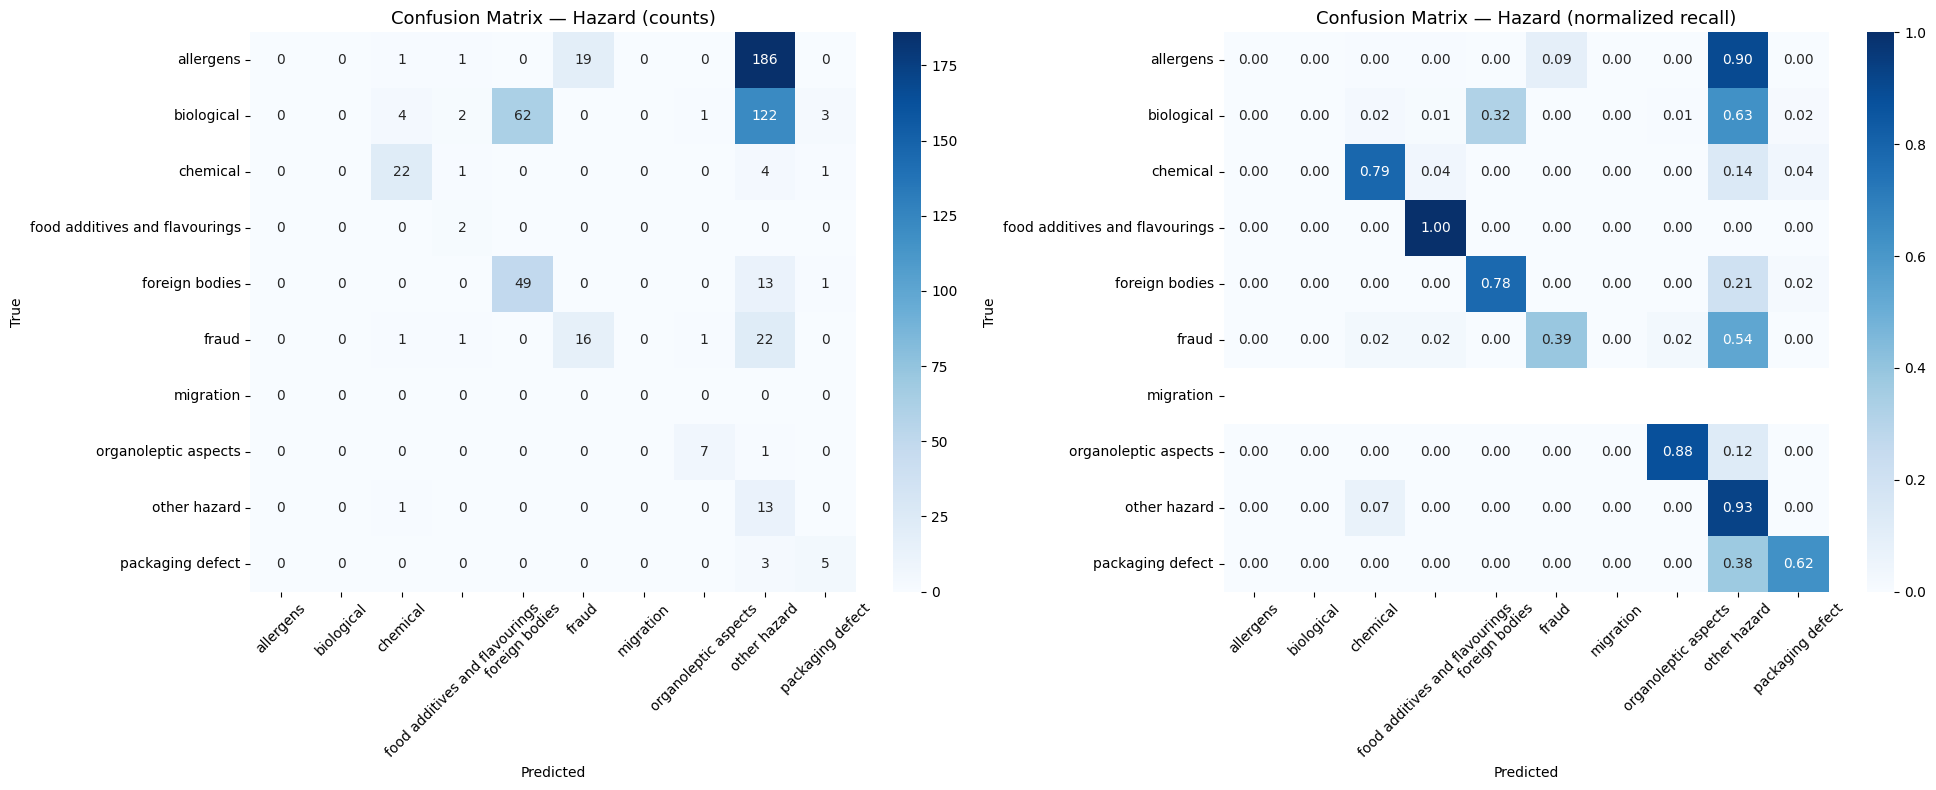

Αποθηκεύτηκε: confusion_matrix_hazard.png


In [15]:
cm_hazard = confusion_matrix(true_hazard, pred_hazard, labels=le_hazard.classes_)

# Normalize ανά row (recall per class)
cm_hazard_norm = cm_hazard.astype('float') / cm_hazard.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Raw counts
sns.heatmap(cm_hazard, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_hazard.classes_,
            yticklabels=le_hazard.classes_,
            ax=axes[0])
axes[0].set_title('Confusion Matrix — Hazard (counts)', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

# Normalized
sns.heatmap(cm_hazard_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le_hazard.classes_,
            yticklabels=le_hazard.classes_,
            ax=axes[1])
axes[1].set_title('Confusion Matrix — Hazard (normalized recall)', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('confusion_matrix_hazard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Αποθηκεύτηκε: confusion_matrix_hazard.png')

## 2. Confusion Matrix — Product (Top 10 κλάσεις)

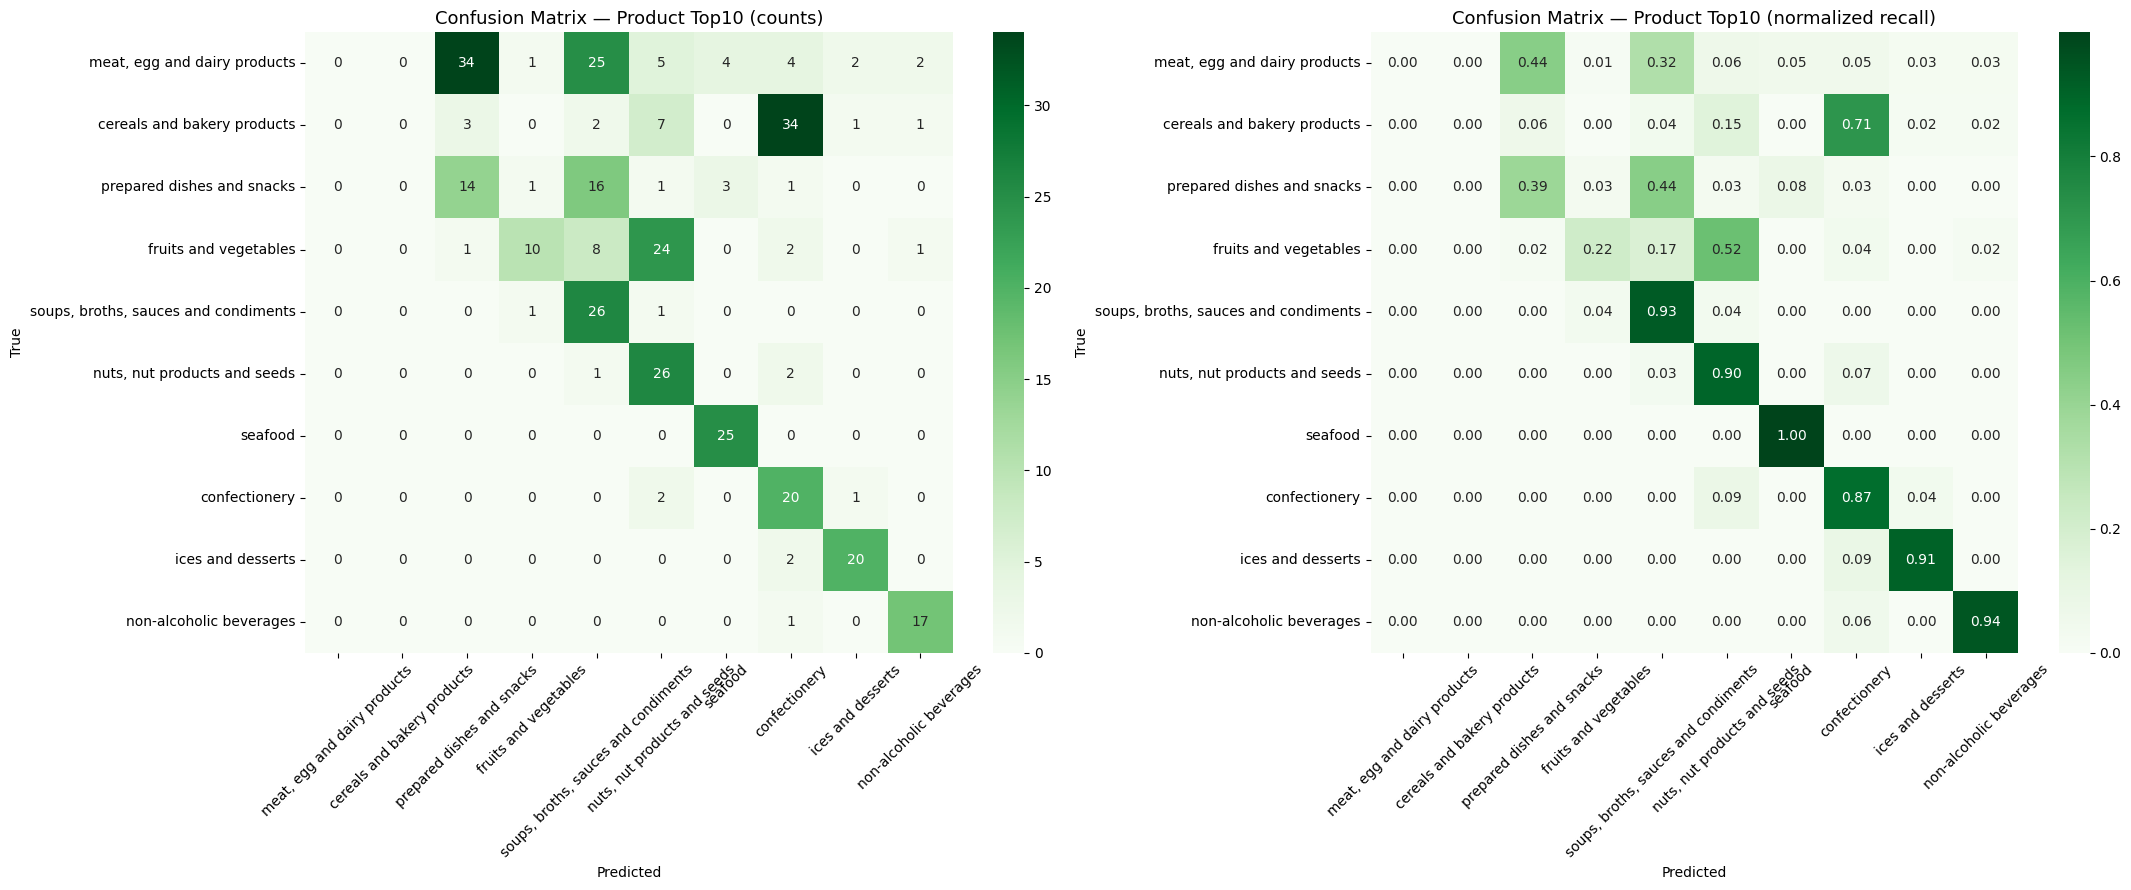

Αποθηκεύτηκε: confusion_matrix_product.png


In [16]:
# Για product δείχνουμε μόνο τις top 10 πιο συχνές κλάσεις
# για να είναι ευανάγνωστο το heatmap
top10_products = valid['product-category'].value_counts().head(10).index.tolist()

mask_top10 = np.isin(true_product, top10_products)
true_product_top10 = true_product[mask_top10]
pred_product_top10 = pred_product[mask_top10]

cm_product = confusion_matrix(true_product_top10, pred_product_top10, labels=top10_products)
cm_product_norm = cm_product.astype('float') / (cm_product.sum(axis=1, keepdims=True) + 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

sns.heatmap(cm_product, annot=True, fmt='d', cmap='Greens',
            xticklabels=top10_products,
            yticklabels=top10_products,
            ax=axes[0])
axes[0].set_title('Confusion Matrix — Product Top10 (counts)', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_product_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=top10_products,
            yticklabels=top10_products,
            ax=axes[1])
axes[1].set_title('Confusion Matrix — Product Top10 (normalized recall)', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('confusion_matrix_product.png', dpi=150, bbox_inches='tight')
plt.show()
print('Αποθηκεύτηκε: confusion_matrix_product.png')

## 3. Class-wise F1 Scores

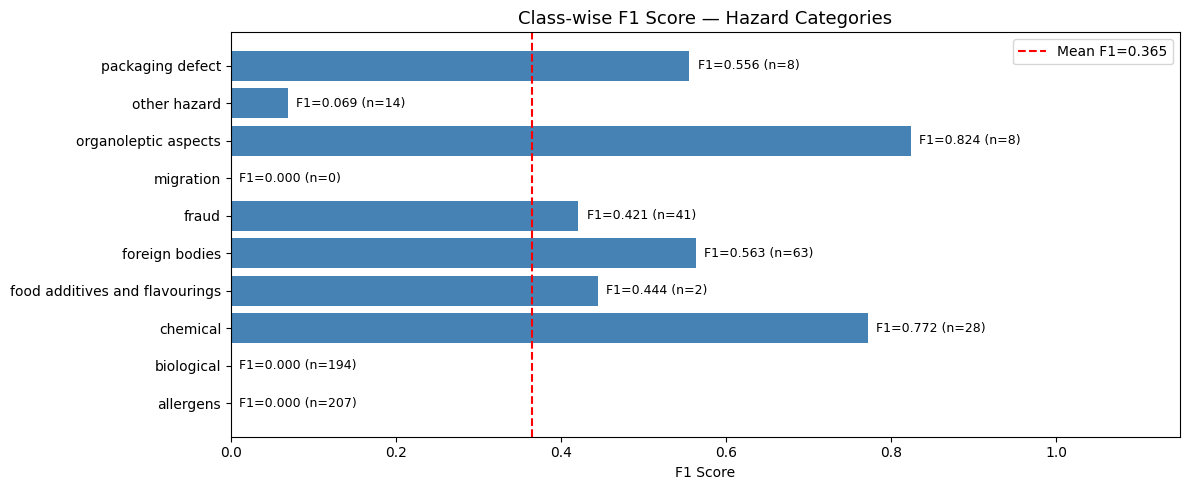


Class-wise F1 — Hazard:
  allergens                           F1=0.000  (n=207)
  biological                          F1=0.000  (n=194)
  migration                           F1=0.000  (n=0)
  other hazard                        F1=0.069  (n=14)
  fraud                               F1=0.421  (n=41)
  food additives and flavourings      F1=0.444  (n=2)
  packaging defect                    F1=0.556  (n=8)
  foreign bodies                      F1=0.563  (n=63)
  chemical                            F1=0.772  (n=28)
  organoleptic aspects                F1=0.824  (n=8)


In [17]:
# Hazard class-wise F1
f1_per_hazard = f1_score(true_hazard, pred_hazard,
                          labels=le_hazard.classes_,
                          average=None, zero_division=0)

hazard_counts = valid['hazard-category'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(le_hazard.classes_, f1_per_hazard, color='steelblue')

# Προσθήκη count labels
for i, (cls, f1) in enumerate(zip(le_hazard.classes_, f1_per_hazard)):
    count = hazard_counts.get(cls, 0)
    ax.text(f1 + 0.01, i, f'F1={f1:.3f} (n={count})', va='center', fontsize=9)

ax.set_xlim(0, 1.15)
ax.axvline(x=f1_per_hazard.mean(), color='red', linestyle='--', label=f'Mean F1={f1_per_hazard.mean():.3f}')
ax.set_xlabel('F1 Score')
ax.set_title('Class-wise F1 Score — Hazard Categories', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('classwise_f1_hazard.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClass-wise F1 — Hazard:')
for cls, f1, count in sorted(zip(le_hazard.classes_, f1_per_hazard,
                                  [hazard_counts.get(c,0) for c in le_hazard.classes_]),
                              key=lambda x: x[1]):
    print(f'  {cls:35s} F1={f1:.3f}  (n={count})')

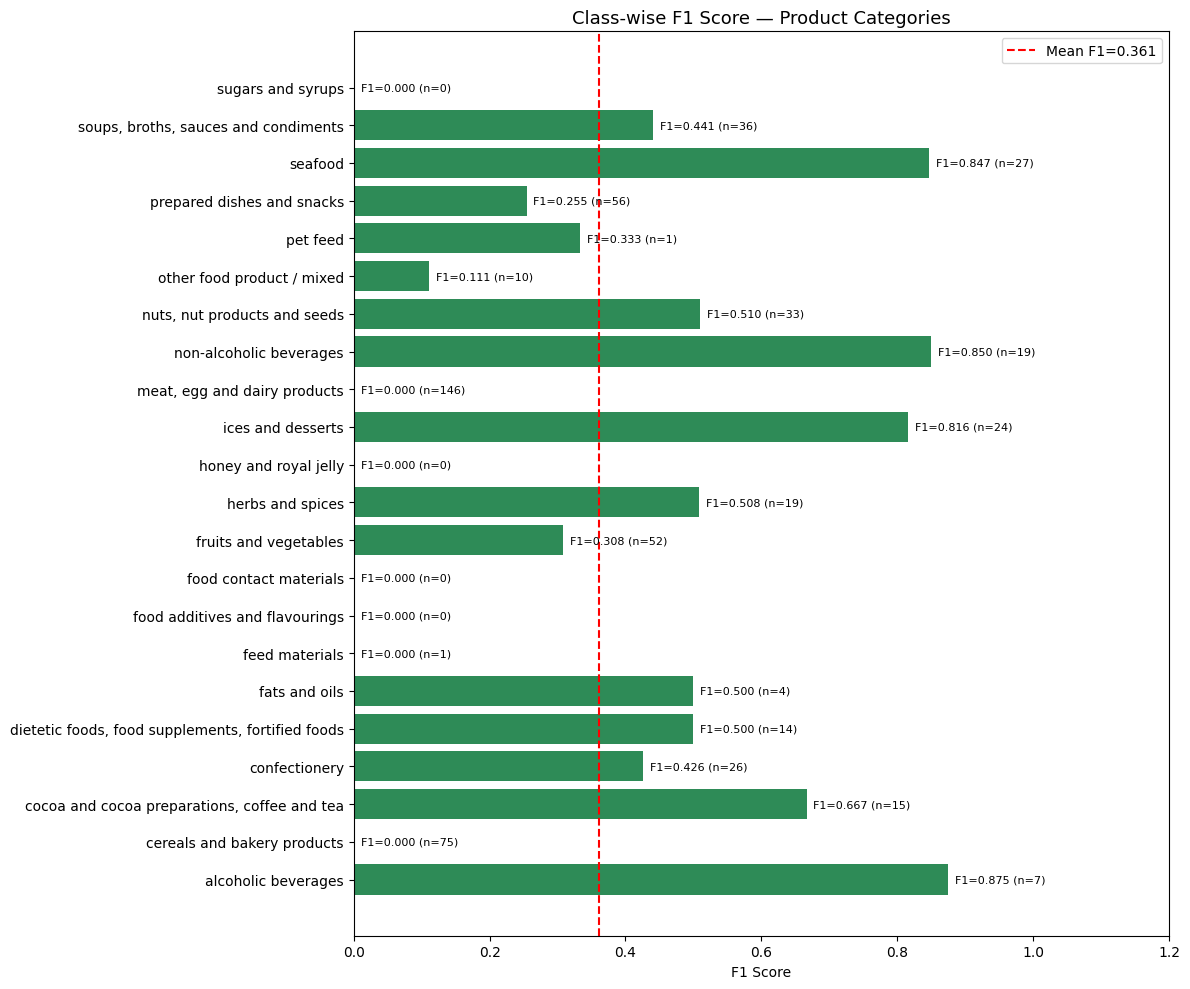


Class-wise F1 — Product (ταξινομημένο):
  cereals and bakery products                   F1=0.000  (n=75)
  feed materials                                F1=0.000  (n=1)
  food additives and flavourings                F1=0.000  (n=0)
  food contact materials                        F1=0.000  (n=0)
  honey and royal jelly                         F1=0.000  (n=0)
  meat, egg and dairy products                  F1=0.000  (n=146)
  sugars and syrups                             F1=0.000  (n=0)
  other food product / mixed                    F1=0.111  (n=10)
  prepared dishes and snacks                    F1=0.255  (n=56)
  fruits and vegetables                         F1=0.308  (n=52)
  pet feed                                      F1=0.333  (n=1)
  confectionery                                 F1=0.426  (n=26)
  soups, broths, sauces and condiments          F1=0.441  (n=36)
  dietetic foods, food supplements, fortified foods F1=0.500  (n=14)
  fats and oils                                 F1

In [18]:
# Product class-wise F1
f1_per_product = f1_score(true_product, pred_product,
                           labels=le_product.classes_,
                           average=None, zero_division=0)

product_counts = valid['product-category'].value_counts()

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(le_product.classes_, f1_per_product, color='seagreen')

for i, (cls, f1) in enumerate(zip(le_product.classes_, f1_per_product)):
    count = product_counts.get(cls, 0)
    ax.text(f1 + 0.01, i, f'F1={f1:.3f} (n={count})', va='center', fontsize=8)

ax.set_xlim(0, 1.2)
ax.axvline(x=f1_per_product.mean(), color='red', linestyle='--', label=f'Mean F1={f1_per_product.mean():.3f}')
ax.set_xlabel('F1 Score')
ax.set_title('Class-wise F1 Score — Product Categories', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('classwise_f1_product.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClass-wise F1 — Product (ταξινομημένο):')
for cls, f1, count in sorted(zip(le_product.classes_, f1_per_product,
                                  [product_counts.get(c,0) for c in le_product.classes_]),
                              key=lambda x: x[1]):
    print(f'  {cls:45s} F1={f1:.3f}  (n={count})')

## 4. Error Analysis

Ποια δείγματα κάνει λάθος το μοντέλο και γιατί;

In [19]:
# Βρες τα λάθη στο hazard
errors_hazard = valid[true_hazard != pred_hazard].copy()
errors_hazard['pred_hazard'] = pred_hazard[true_hazard != pred_hazard]
errors_hazard['true_hazard'] = true_hazard[true_hazard != pred_hazard]

print(f'Σύνολο λαθών στο hazard: {len(errors_hazard)}/{len(valid)} ({100*len(errors_hazard)/len(valid):.1f}%)')
print(f'\n=== Πιο συχνά λάθη (true → predicted) ===')
error_pairs = errors_hazard.groupby(['true_hazard', 'pred_hazard']).size().sort_values(ascending=False)
print(error_pairs.head(10).to_string())

print(f'\n=== 5 παραδείγματα λαθών ===')
for _, row in errors_hazard.head(5).iterrows():
    print(f'\nTitle: {str(row["title"])[:100]}')
    print(f'True:  {row["true_hazard"]}')
    print(f'Pred:  {row["pred_hazard"]}')
    print('-' * 60)

Σύνολο λαθών στο hazard: 451/565 (79.8%)

=== Πιο συχνά λάθη (true → predicted) ===
true_hazard       pred_hazard     
allergens         other hazard        186
biological        other hazard        122
                  foreign bodies       62
fraud             other hazard         22
allergens         fraud                19
foreign bodies    other hazard         13
chemical          other hazard          4
biological        chemical              4
packaging defect  other hazard          3
biological        packaging defect      3

=== 5 παραδείγματα λαθών ===

Title: Recall Notification: FSIS-017-94
True:  biological
Pred:  other hazard
------------------------------------------------------------

Title: Recall Notification: FSIS-048-94
True:  biological
Pred:  other hazard
------------------------------------------------------------

Title: Recall Notification: FSIS-032-95
True:  biological
Pred:  chemical
------------------------------------------------------------

Title: Archive

=== CONFIDENCE ANALYSIS — HAZARD ===
Μέση confidence όταν ΣΩΣΤΟ:  0.467
Μέση confidence όταν ΛΑΘΟΣ: 0.377


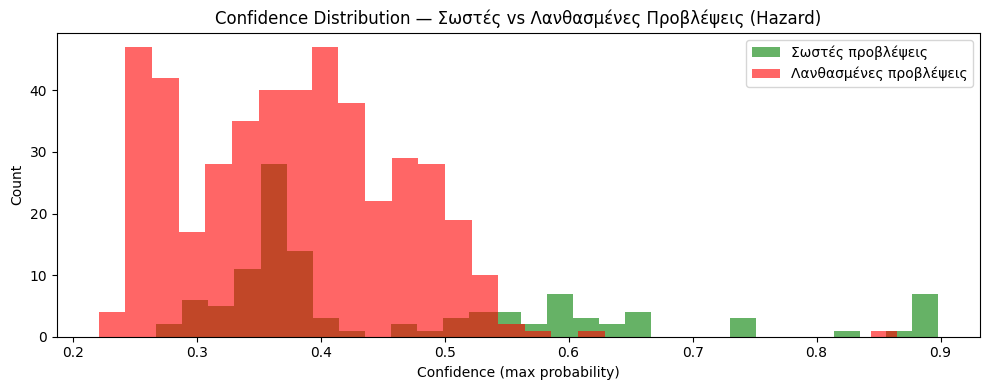

In [20]:
# Confidence analysis — πόσο σίγουρο είναι το μοντέλο όταν κάνει λάθος vs σωστό
max_probs_hazard = valid_hazard_probs.max(axis=1)
correct_mask     = (true_hazard == pred_hazard)

print('=== CONFIDENCE ANALYSIS — HAZARD ===')
print(f'Μέση confidence όταν ΣΩΣΤΟ:  {max_probs_hazard[correct_mask].mean():.3f}')
print(f'Μέση confidence όταν ΛΑΘΟΣ: {max_probs_hazard[~correct_mask].mean():.3f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(max_probs_hazard[correct_mask],  bins=30, alpha=0.6, label='Σωστές προβλέψεις',  color='green')
ax.hist(max_probs_hazard[~correct_mask], bins=30, alpha=0.6, label='Λανθασμένες προβλέψεις', color='red')
ax.set_xlabel('Confidence (max probability)')
ax.set_ylabel('Count')
ax.set_title('Confidence Distribution — Σωστές vs Λανθασμένες Προβλέψεις (Hazard)')
ax.legend()
plt.tight_layout()
plt.savefig('confidence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Ablation Study


=== ABLATION STUDY — Text Input ===
Title only:        0.6950
Text only:         0.6984
Title + Text:      0.7243  ← βέλτιστο

Συμπέρασμα: Το text είναι πιο σημαντικό


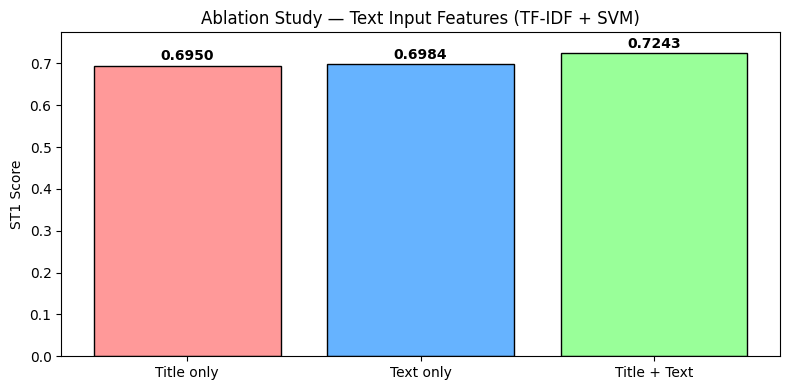

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

def run_tfidf_svm(train_texts, valid_texts):
    tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2),
                             sublinear_tf=True, stop_words='english')
    X_train = tfidf.fit_transform(train_texts)
    X_valid = tfidf.transform(valid_texts)

    clf_h = LinearSVC(C=0.5, class_weight='balanced', max_iter=2000, random_state=42)
    clf_h.fit(X_train, y_train_hazard)
    clf_p = LinearSVC(C=0.5, class_weight='balanced', max_iter=2000, random_state=42)
    clf_p.fit(X_train, y_train_product)

    return clf_h.predict(X_valid), clf_p.predict(X_valid)

y_train_hazard  = train['hazard-category']
y_train_product = train['product-category']

# Ablation 1: Title only
pred_h, pred_p = run_tfidf_svm(train['title'].fillna(''), valid['title'].fillna(''))
score_title = official_st1_score(valid['hazard-category'], pred_h,
                                  valid['product-category'], pred_p, verbose=False)

# Ablation 2: Text only
pred_h, pred_p = run_tfidf_svm(train['text'].fillna('').str[:550],
                                 valid['text'].fillna('').str[:550])
score_text = official_st1_score(valid['hazard-category'], pred_h,
                                 valid['product-category'], pred_p, verbose=False)

# Ablation 3: Title + Text (βέλτιστο)
train_combined = (train['title'].fillna('') + ' ' + train['text'].fillna('').str[:550])
valid_combined = (valid['title'].fillna('') + ' ' + valid['text'].fillna('').str[:550])
pred_h, pred_p = run_tfidf_svm(train_combined, valid_combined)
score_both = official_st1_score(valid['hazard-category'], pred_h,
                                 valid['product-category'], pred_p, verbose=False)

print('\n=== ABLATION STUDY — Text Input ===')
print(f'Title only:        {score_title:.4f}')
print(f'Text only:         {score_text:.4f}')
print(f'Title + Text:      {score_both:.4f}  ← βέλτιστο')
print(f'\nΣυμπέρασμα: {"Το title είναι πιο σημαντικό" if score_title > score_text else "Το text είναι πιο σημαντικό"}')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
labels = ['Title only', 'Text only', 'Title + Text']
scores = [score_title, score_text, score_both]
colors = ['#ff9999', '#66b3ff', '#99ff99']
bars   = ax.bar(labels, scores, color=colors, edgecolor='black')
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('ST1 Score')
ax.set_title('Ablation Study — Text Input Features (TF-IDF + SVM)')
ax.set_ylim(0, max(scores) + 0.05)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Σύνοψη για Αναφορά

In [22]:
print('='*60)
print('ΣΥΝΟΨΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ ΓΙΑ ΑΝΑΦΟΡΑ')
print('='*60)

print('\n1. PROGRESSION OF METHODS (Kaggle scores):')
methods = [
    ('TF-IDF + LogReg (title only)',        0.5761),
    ('TF-IDF + LogReg (title + text)',       0.6523),
    ('Word2Vec + SVM',                       0.4629),
    ('GloVe + SVM',                          0.4618),
    ('FastText + SVM',                       0.4716),
    ('TF-IDF + SVM',                         0.7282),
    ('TF-IDF + SVM (tuned)',                 0.7408),
    ('DistilBERT fine-tuned',                0.7236),
    ('DistilBERT + SVM Ensemble',            0.7547),
    ('DistilBERT (train+valid, 20ep)',       0.7606),
    ('BERT-base + Focal Loss',               0.8040),
    ('BERT-base Focal + DistilBERT Ensemble',0.8055),
    ('Multi-task BERT (35ep)',               0.7706),
    ('BERT-base Focal + Multi-task (0.5/0.5)', 0.8173),
]
for name, score in methods:
    print(f'  {name:45s} {score:.4f}')

print('\n2. ΑΡΧΕΙΑ ΠΟΥ ΑΠΟΘΗΚΕΥΤΗΚΑΝ:')
print('  confusion_matrix_hazard.png')
print('  confusion_matrix_product.png')
print('  classwise_f1_hazard.png')
print('  classwise_f1_product.png')
print('  confidence_analysis.png')
print('  ablation_study.png')

ΣΥΝΟΨΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ ΓΙΑ ΑΝΑΦΟΡΑ

1. PROGRESSION OF METHODS (Kaggle scores):
  TF-IDF + LogReg (title only)                  0.5761
  TF-IDF + LogReg (title + text)                0.6523
  Word2Vec + SVM                                0.4629
  GloVe + SVM                                   0.4618
  FastText + SVM                                0.4716
  TF-IDF + SVM                                  0.7282
  TF-IDF + SVM (tuned)                          0.7408
  DistilBERT fine-tuned                         0.7236
  DistilBERT + SVM Ensemble                     0.7547
  DistilBERT (train+valid, 20ep)                0.7606
  BERT-base + Focal Loss                        0.8040
  BERT-base Focal + DistilBERT Ensemble         0.8055
  Multi-task BERT (35ep)                        0.7706
  BERT-base Focal + Multi-task (0.5/0.5)        0.8173

2. ΑΡΧΕΙΑ ΠΟΥ ΑΠΟΘΗΚΕΥΤΗΚΑΝ:
  confusion_matrix_hazard.png
  confusion_matrix_product.png
  classwise_f1_hazard.png
  classwise_f1_product.png
  confide

# Confusion Matrix Hazard:

- Οι κλάσεις allergens και biological μπερδεύονται συχνά με other hazard — λογικό γιατί το "other hazard" είναι πολύ γενική κατηγορία
- Το fraud έχει recall 0.39 — δύσκολη κλάση
- Το biological έχει recall 0.63 — χάνει πολλά δείγματα στο foreign bodies

# Class-wise F1 Hazard:

- allergens και biological έχουν F1=0.000 παρά τα πολλά δείγματα (n=207, n=194) — το μοντέλο τα ταξινομεί ως other hazard
- organoleptic aspects F1=0.824 με μόλις 8 δείγματα — εντυπωσιακό
- migration F1=0.000 με n=0 στο validation — δεν υπάρχουν δείγματα

# Class-wise F1 Product:

- meat, egg and dairy products F1=0.000 με n=146 — μεγάλο πρόβλημα
- cereals and bakery products F1=0.000 με n=75 — επίσης
- seafood F1=0.847 και non-alcoholic beverages F1=0.850 — πολύ καλά

# Confidence Analysis:

- Τα λάθη έχουν confidence 0.25-0.50 — το μοντέλο είναι αβέβαιο όταν κάνει λάθος 
- Τα σωστά έχουν confidence 0.55-0.90 — καλά calibrated

# Ablation Study:

- Title+Text: 0.7243 > Text only: 0.6984 > Title only: 0.6950
- Η διαφορά title vs text είναι μικρή — και τα δύο είναι σημαντικά